# [Decision Variable Prediction] Figure 5

## The amount of information available to the mouse correlates inversely with infotaxis behavior. 

For reference, here is the full figure

![dual_occlusion](final_figures/multi_occlusion.jpg) 

and corresponding supplemental figure

![Supplemental dual_occlusion](final_figures/supp_multi_occlusion.jpg)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-12 14:44:57,300][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-05-12 14:44:57,415][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.decision import InclusionStatus, ExperimentMember, LabelSet, Label, PredictionModel10Windows, DecisionPoints10Windows

from statsmodels.stats.anova import AnovaRM
import scipy.stats as stats
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from vr4mice.analysis import regression

from scipy.stats import pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable

from vr4mice.analysis.stats import get_multi_p_values_global, get_multi_p_values_binned, plot_aperture_heatmap

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
task_type_key = {"set_name": "contrast_white_target",
                 "stage_name": "multi_occlusion",}

In [6]:
sessions_list = list(
                (InclusionStatus * ExperimentMember & {"included": 1} & task_type_key).fetch(
                    "dataset"
                )
            )

len(sessions_list)

25

In [7]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in sessions_list:
    print(d)
    try:
        dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

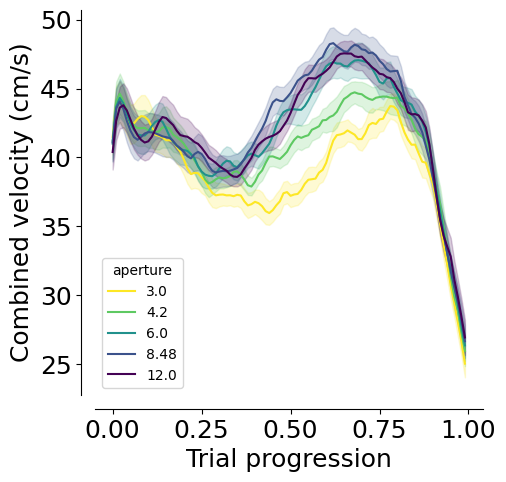

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = ax
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

mean_mouse.sort_values("aperture", inplace=True)
mean_mouse["aperture"] = mean_mouse.aperture.astype("str")

sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "figure5_velocity.svg", transparent=False)

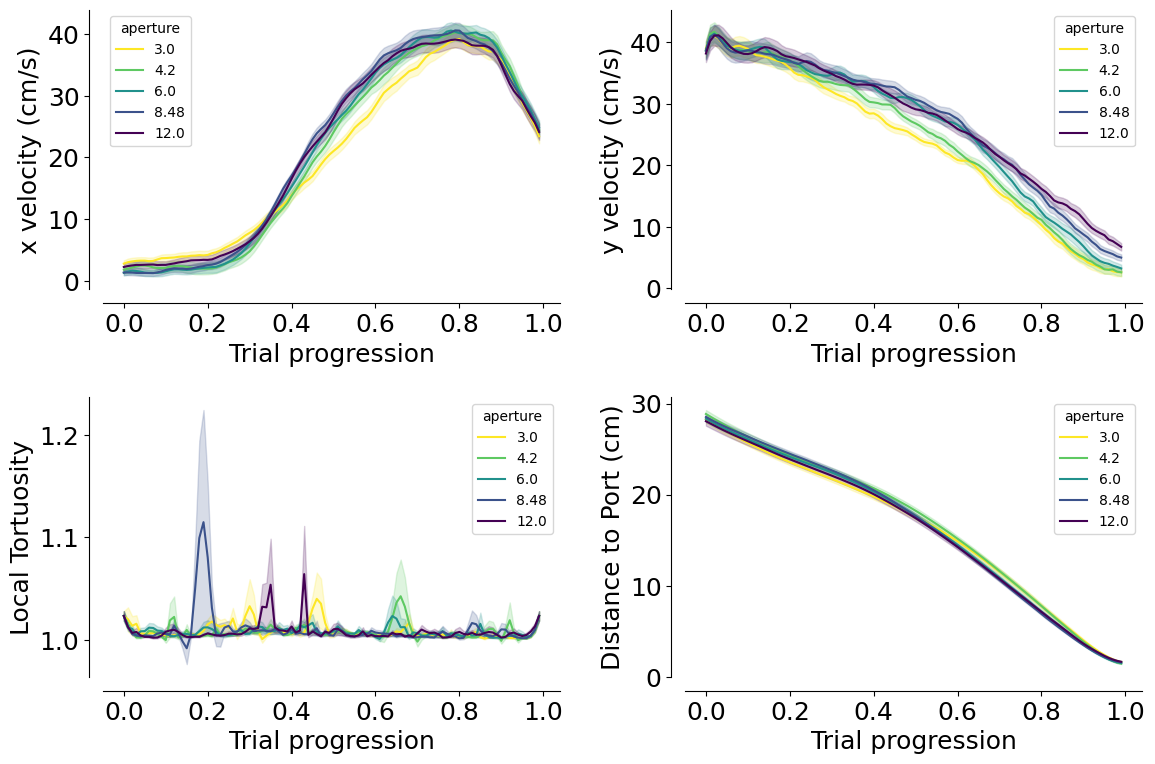

In [10]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_multi_aperture
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

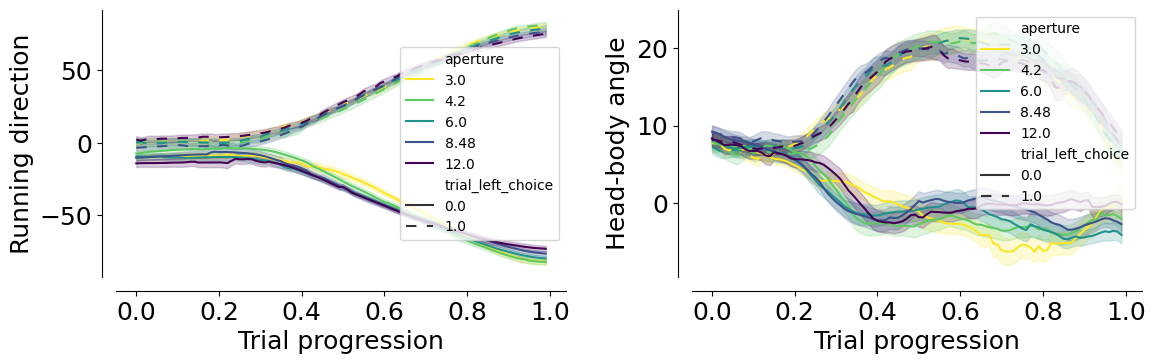

In [11]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction", "Head-body angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)

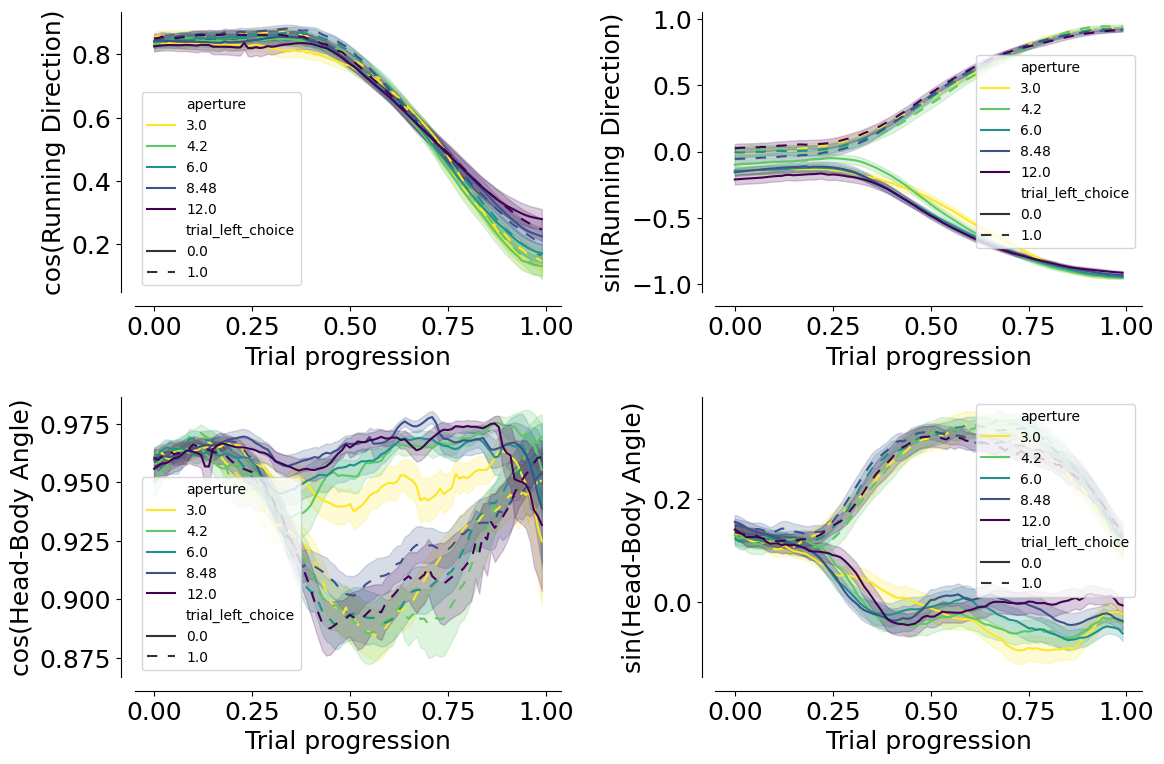

In [12]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.trial_left_choice.unique()[0]: "",         # Solid
    mean_mouse.trial_left_choice.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
        dashes=dash_styles,
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure5_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [13]:
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

optimal_df =  interpolated_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  interpolated_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

In [14]:
optimal_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.1376 4.0000 96.0000 0.0180



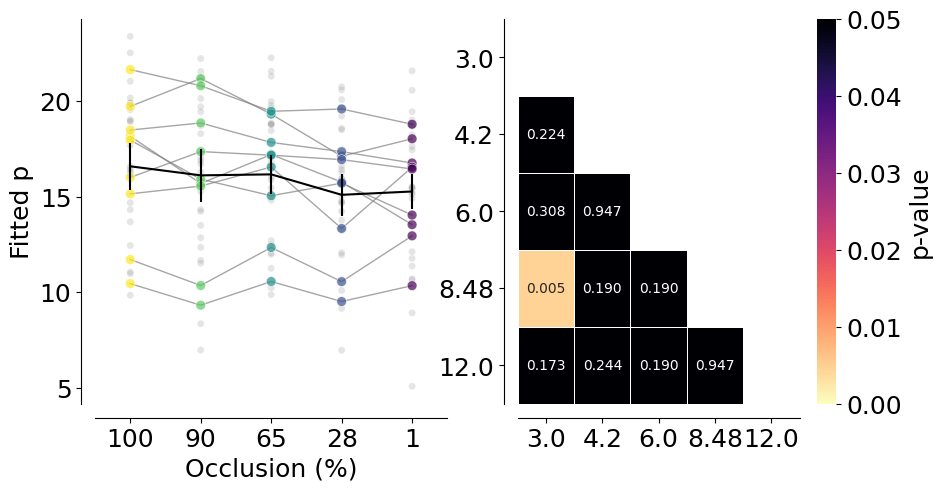

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(optimal_df, y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])
sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(save_fig_path + "figure5_fitted_p.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.1376 4.0000 96.0000 0.0180



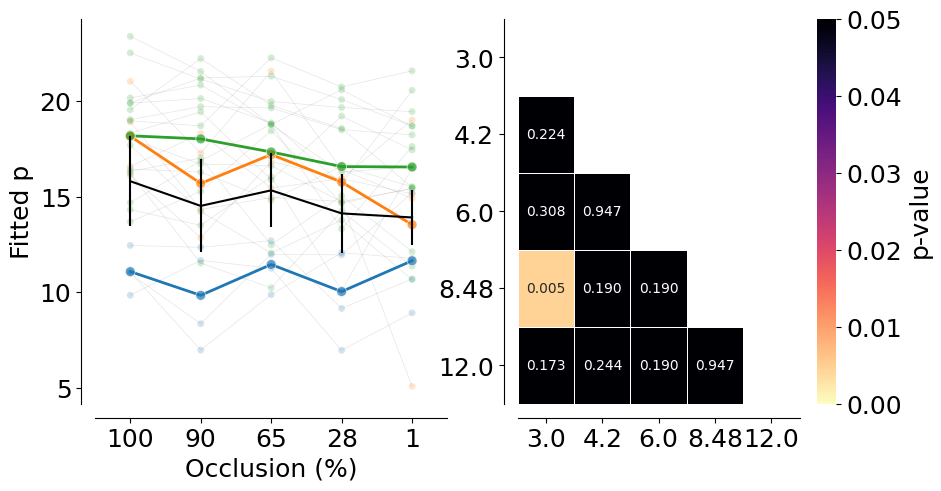

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    optimal_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)

ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(optimal_df,  y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(
    save_fig_path + "figure5_fitted_p_per_lab.svg",
    transparent=True,
)

## Prediction model

In [17]:
model_key = {"label_set_id": 8, "params_id": 1}

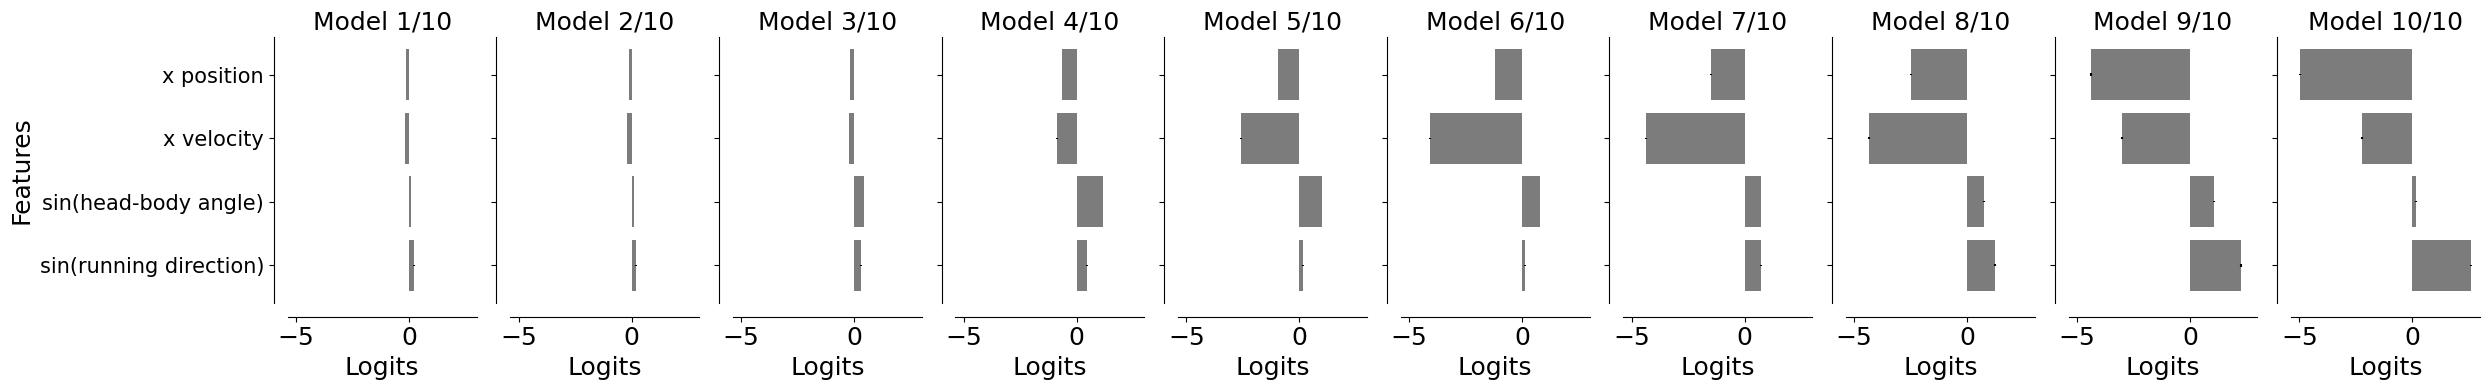

In [18]:
coefs = (PredictionModel10Windows() & task_type_key & model_key).fetch("coefficients_by_window")[0]
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 10, figsize=(25, 4), sharey=True, sharex=True)
ax = ax.flatten()
for axis, key in zip(ax, coefs.keys()):
    
    axis.barh(
        model_labels,
        np.mean(coefs[key][:, 1:], axis=0),
        yerr=stats.sem(coefs[key][:, 1:], axis=0),
        color="#7C7C7C",
    )
    sns.despine(offset=10, ax=axis)

    axis.set_yticks(np.arange(len(model_labels)))
    axis.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
    axis.set_xlabel("Logits")
    if key == 0:
        axis.set_ylabel("Features")
    else:
        axis.set_ylabel("")
    axis.set_title(f"Model {key+1}/10")
plt.tight_layout()

plt.savefig(
    save_fig_path + "figure5_model_logits.svg", transparent=False
)

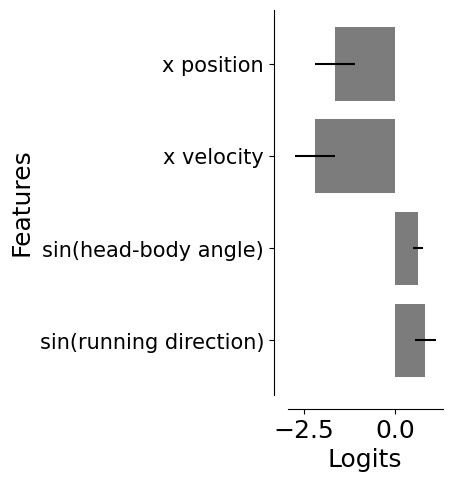

In [19]:
# Average across windows
mean_coef = np.array([np.mean(coefs[key], axis=0) for key in coefs.keys()])

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(mean_coef[:, 1:], axis=0),
    xerr=stats.sem(mean_coef[:, 1:], axis=0), # sem across windows
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")
plt.savefig(
    save_fig_path + "figure5_model_logits_average.svg", transparent=False
)

In [20]:
prediction_df = pd.DataFrame((PredictionModel10Windows().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [21]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

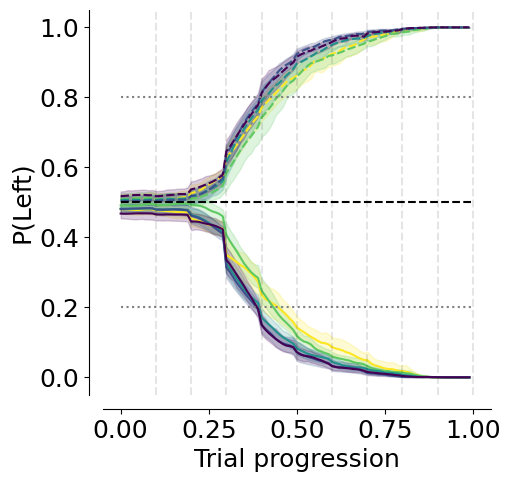

In [22]:
df_model_mean = df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    df_model_mean.aperture.unique()[0]: "",         # Solid
    df_model_mean.aperture.unique()[1]: (5, 5)      # Dashed
}
    
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="aperture",
    style="trial_left_choice",
    palette=plotting.colors_multi_aperture,
    sort=False,
    alpha=1,
    ax=ax,
)

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.8, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.2, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.set_ylabel("P(Left)")
ax.set_xlabel("Trial progression")

for i in range(10):
    plt.axvline((i+1)/10, color="k", linestyle="dashed", alpha=0.1)
    
    
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure5_dynamic_decision_variable_mean.svg", transparent=True
)
plt.savefig(
    save_fig_path + "figure5_dynamic_decision_variable_mean.png", transparent=True, 
    dpi=300, bbox_inches="tight"
)

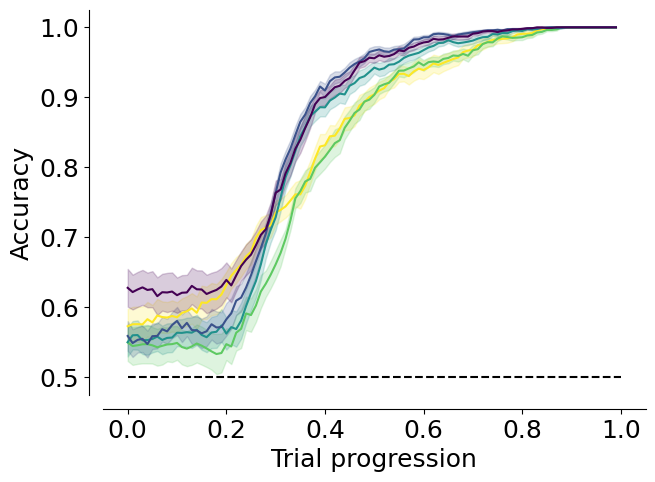

In [23]:
# Accuracy
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sns.lineplot(
    ax=ax,
    data=df_model_mean,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
ax.hlines(0.5, 0, 1, color="black", linestyle="--")
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure5_model_accuracy.svg", transparent=False
)

In [24]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)

df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
).mean(numeric_only=True)

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                          F Value   Num DF    Den DF  Pr > F
------------------------------------------------------------
aperture                   10.9240   4.0000   96.0000 0.0000
trial_length_bin          428.4677  49.0000 1176.0000 0.0000
aperture:trial_length_bin   4.3504 196.0000 4704.0000 0.0000



## Get the decision points

In [25]:
decision_points = pd.DataFrame((DecisionPoints10Windows() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]
decision_points["y"] = decision_points["y"].astype(float)

### Get distance to screen at decision point

3.0-4.2: TtestResult(statistic=0.5987815529023436, pvalue=0.5549287227895707, df=24)
 mean difference:  -0.530209209685669
3.0-6.0: TtestResult(statistic=1.9616704924287043, pvalue=0.06150015681928135, df=24)
 mean difference:  -1.641764740969215
3.0-8.48: TtestResult(statistic=4.028730666964106, pvalue=0.0004899981672967275, df=24)
 mean difference:  -2.857635054226302
mean: 13.07337870951966 +/- 0.5596577966523296
4.2-6.0: TtestResult(statistic=1.446631528234131, pvalue=0.16093539133628174, df=24)
 mean difference:  -1.1115555312835461
4.2-8.48: TtestResult(statistic=3.304708103565422, pvalue=0.002977487493312889, df=24)
 mean difference:  -2.327425844540633
mean: 12.543169499833992 +/- 0.5264455819036392
6.0-8.48: TtestResult(statistic=1.7618659320159529, pvalue=0.09082687791706283, df=24)
 mean difference:  -1.2158703132570867
mean: 11.431613968550446 +/- 0.5134676384371734
mean: 10.215743655293359 +/- 0.4828821026144371
12.0-3.0: TtestResult(statistic=-4.339891610862501, pvalue=0.

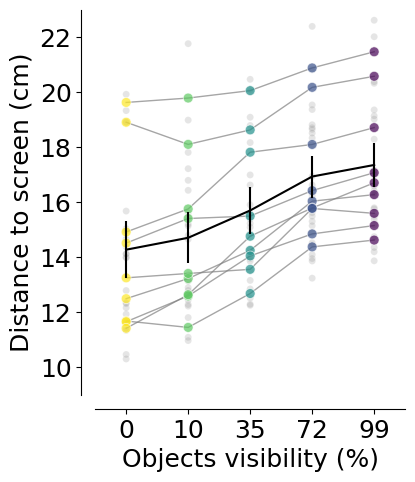

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.set_xlabel("Objects visibility (%)")
ax.set_ylim(9, 23)
ax.set_xlim(-0.5, 4.5)
ax.set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure5_decision_points_distance.svg",
    transparent=True,
)

In [27]:
decision_points["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

In [28]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

3.0-4.2: TtestResult(statistic=1.8557892747822982, pvalue=0.0758049713230524, df=24)
 mean difference:  -0.5302092096856672
3.0-6.0: TtestResult(statistic=4.534871797709288, pvalue=0.0001355339425674299, df=24)
 mean difference:  -1.641764740969215
3.0-8.48: TtestResult(statistic=8.416034440477477, pvalue=1.2716933602553742e-08, df=24)
 mean difference:  -2.857635054226302
mean: 13.07337870951966 +/- 0.5596577966523296
4.2-6.0: TtestResult(statistic=3.2277384804773206, pvalue=0.0035909650587082342, df=24)
 mean difference:  -1.111555531283548
4.2-8.48: TtestResult(statistic=5.692060259579012, pvalue=7.298885576659157e-06, df=24)
 mean difference:  -2.3274258445406346
mean: 12.543169499833994 +/- 0.5264455819036392
6.0-8.48: TtestResult(statistic=5.0857876609568615, pvalue=3.3451805311630066e-05, df=24)
 mean difference:  -1.2158703132570867
mean: 11.431613968550446 +/- 0.5134676384371734
mean: 10.215743655293359 +/- 0.4828821026144371
12.0-3.0: TtestResult(statistic=-10.05664639191916,

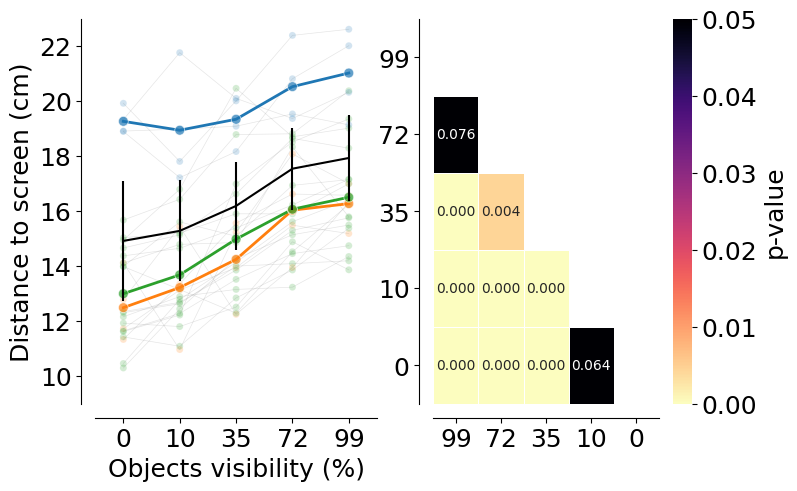

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].set_ylim(9, 23)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])
plt.legend([], [], frameon=False)
ax[0].set_xlabel("Objects visibility (%)")
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_p_values_global(decision_points,  y_var="y")
plot_aperture_heatmap(p_values, ax= ax[1])
ax[1].set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ["99", "72", "35", "10", "0"])
ax[1].set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ["99", "72", "35", "10", "0"])
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=90)
sns.despine(offset=10, ax=ax[1])

decision_points_anova = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
print(AnovaRM(decision_points_anova, depvar="y", subject="dataset", within=["aperture"]).fit())


plt.savefig(
    save_fig_path + "figure5_decision_points_distance_per_lab.svg",
    transparent=True,
)

In [30]:
info_matrices = []
for ap in ["8.7", "12.3", "17.3", "24.5", "34.6"]:
    with open(f"information_maps/data/info_matrix_unnormalized_{ap}w.npy", "rb") as file:
        info_matrix = np.rot90(np.load(file), k=1)
        info_matrices.append(info_matrix)

# normalize across both maps to max 1
max_value = max(im.max() for im in info_matrices)
info_matrices = [im / max_value for im in info_matrices]

info_map = dict(zip([0, 10, 35, 72, 99], info_matrices))

/tmp/ipykernel_2557782/1864239500.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap("PuOr")


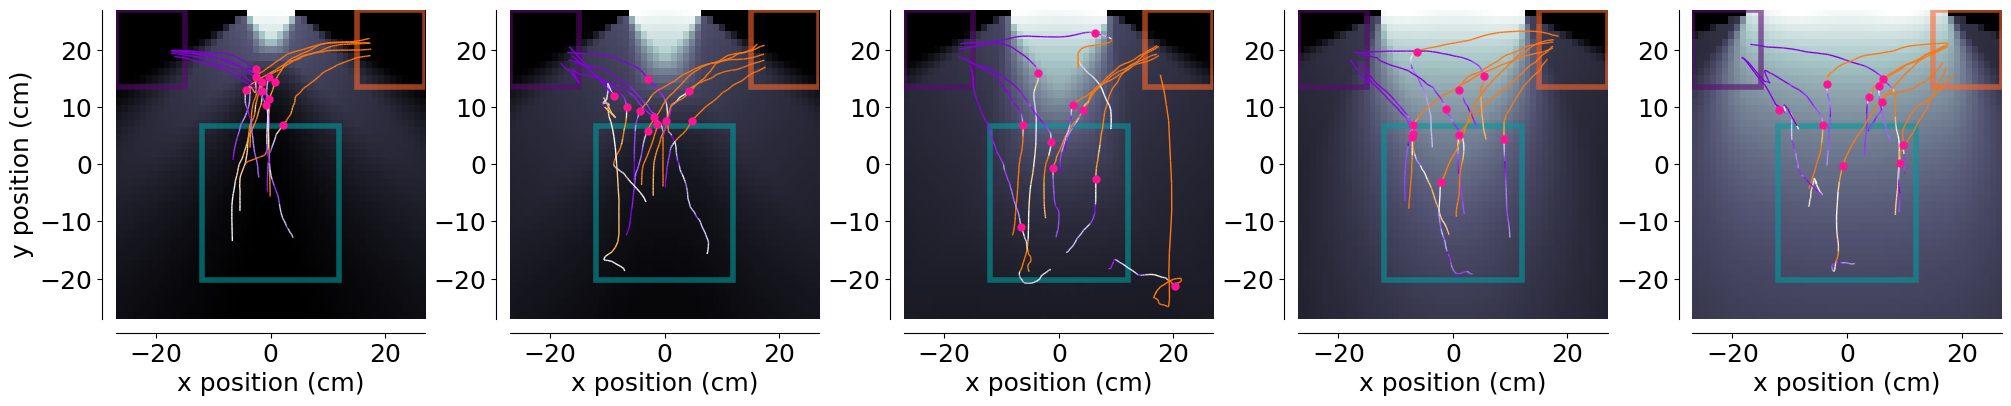

In [31]:
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(20, 4), constrained_layout=True,
)

decision_color = "deeppink"
session_to_plot = "Nightingale_2024-08-16_1"

# Pick 15 trials for each condition randomly (fixed seed for reproducibility)
np.random.seed(0)
trials = []
for aperture in sorted(df_model.aperture.unique()):
    ap_trials = df_model[
        (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
    ]["trial"].unique()
    selected_trials = np.random.choice(ap_trials, size=10, replace=False)
    trials.extend(selected_trials)

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=3):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(sorted(df_model.aperture.unique())):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )

    im = ax[i].imshow(info_map[aperture_to_occlusion[aperture]], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(-27, 27)
    ax[i].set_ylim(-27, 27)
    #ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("")
    #ax[i].set_title(f"Aperture {aperture_to_occlusion[aperture]}%")
    sns.despine(offset=10, ax=ax[i])

ax[0].set_ylabel("y position (cm)")
plt.savefig(
    save_fig_path + "figure5_decision_points_trajectories_bright.svg",
    transparent=True,
)

In [32]:
def get_info_at_position(info_matrix, position):
    # Assuming info_matrix is a 2D numpy array and position is a tuple (x, y)
    x, y = position
    # Convert position to matrix indices
    x_idx = int(x + 27)
    y_idx = int(y + 27)
    
    # but the matrix is 52x42 so the positions need to be scaled down
    x_idx_norm = int(x_idx * (51 / 54))
    y_idx_norm = int(y_idx * (41 / 54))
    
    y_idx_norm = info_matrix.shape[0] - 1 - y_idx_norm
    return info_matrix[y_idx_norm, x_idx_norm]  # Note: y comes first in matrix indexing

In [33]:
# Compute information for each timepoint in interpolated_df
interpolated_df["info_gain"] = interpolated_df.apply(
    lambda row: get_info_at_position(
        info_map[aperture_to_occlusion[row.aperture]],
        (row.x, row.y),
    ),
    axis=1,
)

In [34]:
decision_points.dropna(subset=["x", "y"], inplace=True)
decision_points["info_gain"] = decision_points.apply(
    lambda row: get_info_at_position(
        info_map[aperture_to_occlusion[row.aperture]],
        (row.x, row.y),
    ),
    axis=1,
)

In [35]:
# Convert to sec
interpolated_df["time_in_sec"] = interpolated_df["trial_length"] * interpolated_df["trial_duration"]

durations = interpolated_df[["dataset", "trial", "trial_duration"]].drop_duplicates()
decision_points = decision_points.merge(durations, on=["dataset", "trial"], how="left")
decision_points["time_in_sec"] = decision_points["trial_length"] * decision_points["trial_duration"]

In [36]:
interpolated_df["distance_to_screen"] = np.abs(interpolated_df["y"] - 27)

In [37]:
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]
interpolated_df["heading_dir_flipped"] = interpolated_df.heading_dir * interpolated_df.flip_one_side
interpolated_df["head_angle_flipped"] = interpolated_df.head_angle * interpolated_df.flip_one_side

In [38]:
decision_points["distance_to_screen"] = np.abs(decision_points["y"].astype(float) - 27)

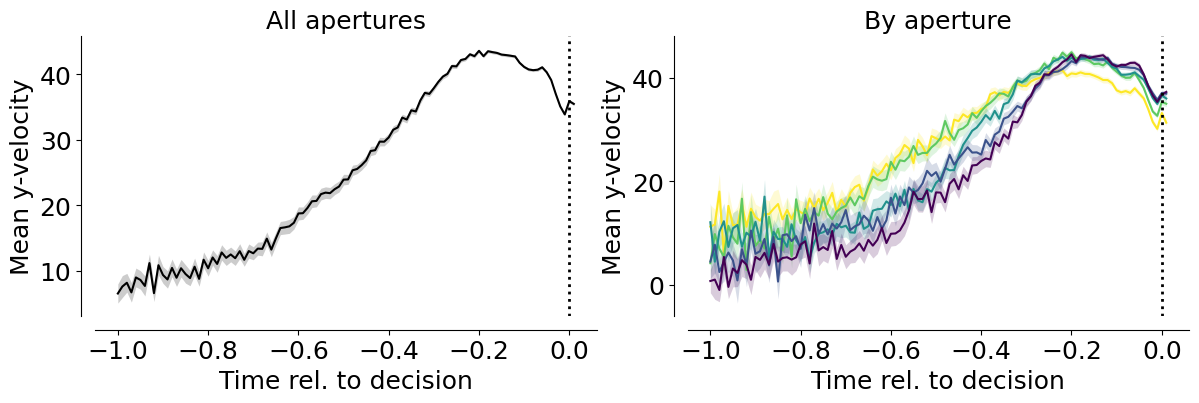

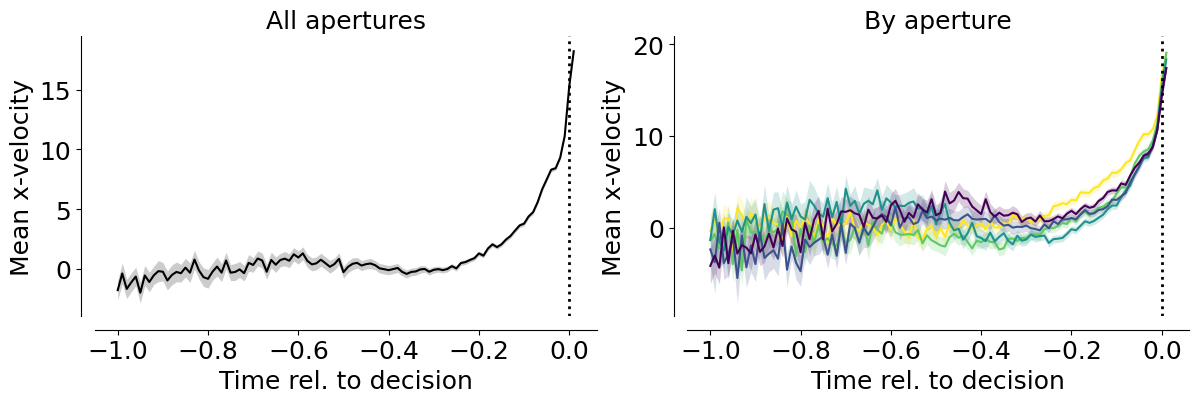

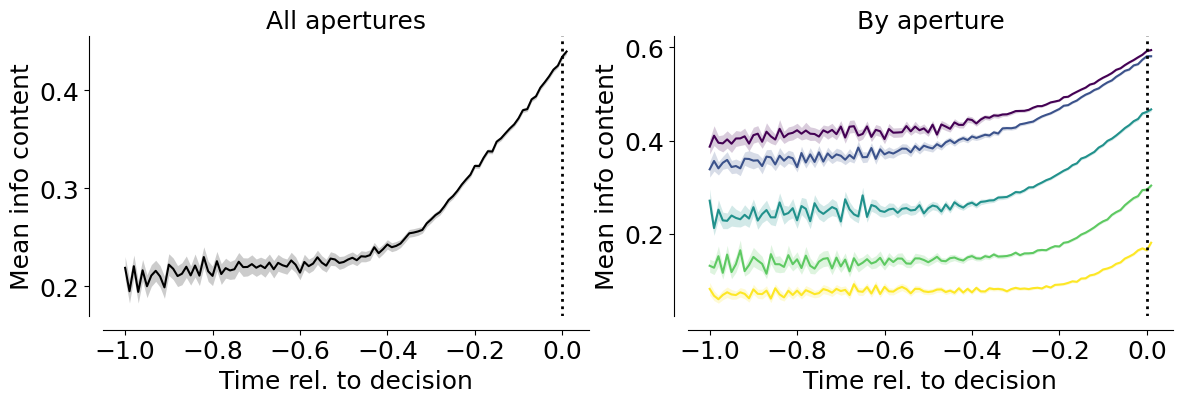

In [39]:
# Average velocity/info_gain around decision point
bin_size = 0.01
pre_window = 1
post_window = 0.02

dp_all = decision_points[["dataset", "aperture", "trial", "time_in_sec"]].rename(
    columns={"time_in_sec": "decision_tl"}
)

df_all = interpolated_df.merge(
    dp_all,
    on=["dataset", "aperture", "trial"],
    how="inner",
).copy()

df_all["t_rel"] = df_all["time_in_sec"] - df_all["decision_tl"]
df_all = df_all[(df_all.t_rel >= -pre_window) & (df_all.t_rel <= post_window)]

bins = np.arange(-pre_window, post_window + bin_size, bin_size)
df_all["t_bin"] = pd.cut(df_all.t_rel, bins=bins, labels=bins[:-1])

def _bin_mean_sem(frame, value_col):
    binned = (
        frame.groupby(["aperture", "t_bin"])[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    binned["t_bin"] = binned["t_bin"].astype(float)
    return binned

metrics = [
    {
        "col": "velocity_y",
        "ylabel": "Mean y-velocity",
        "file": "figure4_velocity_around_decision.svg",
    },
    {
        "col": "velocity_x_fliped",
        "ylabel": "Mean x-velocity",
        "file": "figure4_velocity_x_around_decision.svg",
    },
    {
        "col": "info_gain",
        "ylabel": "Mean info content",
        "file": "figure4_info_gain_around_decision.svg",
    },
]

binned_by_metric = {}
for metric in metrics:
    value_col = metric["col"]
    binned = _bin_mean_sem(df_all, value_col)
    binned_by_metric[value_col] = binned
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    # Overall
    overall = (
        df_all.groupby("t_bin")[value_col]
        .agg(["mean", "sem"])
        .reset_index()
    )
    overall["t_bin"] = overall["t_bin"].astype(float)
    axes[0].plot(overall.t_bin, overall["mean"], color="black", linewidth=1.5)
    axes[0].fill_between(
        overall.t_bin,
        overall["mean"] - overall["sem"],
        overall["mean"] + overall["sem"],
        color="black",
        alpha=0.2,
        linewidth=0,
    )
    axes[0].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[0].set_title("All apertures")
    axes[0].set_ylabel(metric["ylabel"])
    axes[0].set_xlabel("Time rel. to decision")
    sns.despine(ax=axes[0])

    # By aperture
    for color, (idx, ap) in zip(plotting.colors_multi_aperture, enumerate(sorted(df_all.aperture.unique()))):
        ap_df = binned[binned.aperture == ap]
        axes[1].plot(ap_df.t_bin, ap_df["mean"], color=color, linewidth=1.5, label=f"Aperture {ap}")
        axes[1].fill_between(
            ap_df.t_bin,
            ap_df["mean"] - ap_df["sem"],
            ap_df["mean"] + ap_df["sem"],
            color=color,
            alpha=0.2,
            linewidth=0,
        )
    axes[1].axvline(0, color="black", linestyle=":", linewidth=2)
    axes[1].set_title("By aperture")
    axes[1].set_xlabel("Time rel. to decision")
    axes[1].set_ylabel(metric["ylabel"])
    sns.despine(ax=axes[1])

    plt.tight_layout()
    sns.despine(offset=10)
    plt.savefig(save_fig_path + metric["file"])


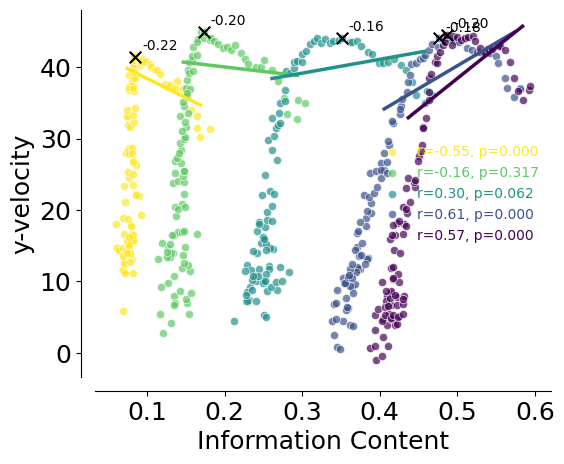

In [40]:
# Correlation between velocity and info gain (binned means)
vel_binned = binned_by_metric["velocity_y"]
info_binned = binned_by_metric["info_gain"]
corr_df = vel_binned.merge(
    info_binned,
    on=["aperture", "t_bin"],
    suffixes=("_vel", "_info"),
)

# Define your correlation window here
corr_window = (-0.4, 0.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
divider = make_axes_locatable(ax)
apertures_sorted = sorted(corr_df.aperture.unique())


for color, (i, ap) in zip(plotting.colors_multi_aperture, enumerate(apertures_sorted)):
    # Full data for the scatter plot
    ap_df = corr_df[corr_df.aperture == ap].dropna(subset=["mean_info", "mean_vel"])
    if ap_df.empty:
        continue
    
    # Find the row with the maximum velocity for this aperture
    max_row = ap_df.loc[ap_df["mean_vel"].idxmax()]
    max_x = max_row["mean_info"]
    max_y = max_row["mean_vel"]
    max_time = max_row["t_bin"]
    
    ax.scatter(max_x, max_y, marker='x', s=70, color='black', 
                zorder=10)
    ax.annotate(
        f"{max_time:.2f}", 
        xy=(max_x, max_y), 
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
    )
    
    # Subset data for Pearson Correlation and Regression
    mask = (ap_df.t_bin >= corr_window[0]) & (ap_df.t_bin <= corr_window[1])
    stat_df = ap_df[mask]
    
    if not stat_df.empty:
        r_coeff, p_val = pearsonr(stat_df["mean_info"], stat_df["mean_vel"])
        label_str = f"r={r_coeff:.2f}, p={p_val:.3f}"
        
        # Plot regression line ONLY for the correlation window
        slope, intercept = np.polyfit(stat_df["mean_info"], stat_df["mean_vel"], 1)
        x_range = np.linspace(stat_df["mean_info"].min(), stat_df["mean_info"].max(), 10)
        ax.plot(x_range, slope * x_range + intercept, 
                color=color, linewidth=2.5, zorder=5)

    # Plot ALL scatter points
    sc = ax.scatter(
        ap_df["mean_info"],
        ap_df["mean_vel"],
        c=color,
        s=35,
        linewidths=0.6,
        label=label_str,
        edgecolor="white",
        alpha=0.7
    )

ax.set_xlabel("Information Content")
ax.set_ylabel("y-velocity")
leg = ax.legend(frameon=False)

for i, text in enumerate(leg.get_texts()):
    ap_key = apertures_sorted[i]
    text.set_color(plotting.colors_multi_aperture[i])

sns.despine(offset=10)
plt.tight_layout(pad=2.0)

plt.savefig(save_fig_path + "figure5_info_velocity_correlation_y.svg", transparent=True)